# 07. MCMC の直感 — 事後分布の上を歩く

## この章で分かること

- なぜ MCMC が必要か(共役が使えない世界では事後分布が「計算できない」)
- **Metropolis-Hastings** を 20 行で自作し、動きを観察する
- 提案幅と受容率のトレードオフ、burn-in、自己相関
- **Gibbs サンプリング** と **HMC / NUTS** の発想

## 1. なぜ MCMC か

ベイズの定理の分母(正規化定数)は

$$
p(x) = \int p(x \mid \theta)\, p(\theta)\, d\theta
$$

という積分で、モデルが少し複雑になるだけで解けなくなります。
MCMC の発想は大胆です:

> 事後分布の **式** を求めるのは諦める。
> 代わりに、事後分布に従う **サンプル** を引けるようにする。

サンプルさえあれば、平均も信用区間も $P(\theta > 0.5)$ も全部ヒストグラムから読めます
(03 章の A/B テストで既にやったことです)。

鍵: MCMC が必要とするのは $p(\theta \mid x)$ の **比** だけ。比を取ると分母 $p(x)$ が消えるので、
**正規化定数を知らないまま** サンプリングできます。

In [1]:
# Shared setup.
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
from scipy import stats

from bayes_textbook import visualization as viz
from bayes_textbook.conjugacy import BetaBinomial
from bayes_textbook.models import (
    autocorrelation, gibbs_bivariate_normal, leapfrog, metropolis_hastings,
)

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 2. Metropolis-Hastings — 酔歩 + 賢い門番

ランダムウォーク MH のルールはこれだけ:

1. 現在地 $\theta$ の近くに候補 $\theta'$ を提案(例: $\theta' = \theta + \mathcal{N}(0, s^2)$)
2. 受容確率 $\min\!\left(1, \dfrac{p(\theta' \mid x)}{p(\theta \mid x)}\right)$ で移動、ダメなら留まる

「高い方へは必ず行く、低い方へも **たまに** 行く」。
この単純な門番だけで、滞在時間の分布が事後分布に一致します(理由は §7)。

03 章のベータ二項の事後を **閉形式を知らないふりをして** MH でサンプリングし、
正解(閉形式)と照合します。

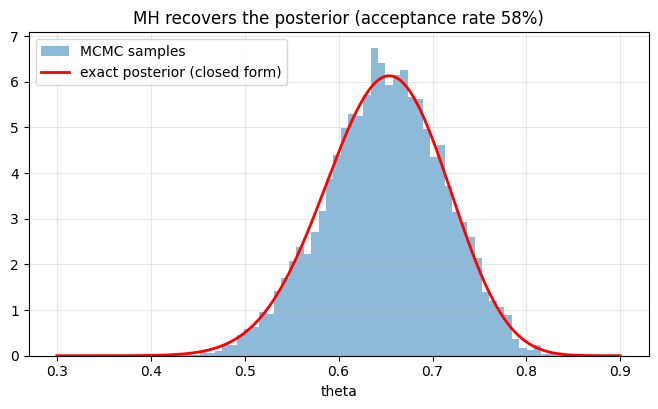

MCMC mean = 0.6494   exact mean = 0.6481


In [2]:
# MH on the beta-binomial posterior (pretending we can't do it in closed form).
s_obs, f_obs = 33, 17
prior_a, prior_b = 2, 2


def log_posterior(theta):
    # log prior + log likelihood, unnormalized; -inf outside (0, 1).
    if theta <= 0 or theta >= 1:
        return -np.inf
    return ((prior_a - 1 + s_obs) * np.log(theta)
            + (prior_b - 1 + f_obs) * np.log(1 - theta))


samples, accept_rate = metropolis_hastings(log_posterior, x0=0.5, n_steps=20_000,
                                           proposal_sd=0.1, seed=0)
exact = BetaBinomial(prior_a, prior_b).update(s_obs, f_obs)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(samples[1000:], bins=60, density=True, alpha=0.5, label="MCMC samples")
th = np.linspace(0.3, 0.9, 300)
ax.plot(th, exact.dist.pdf(th), "r", lw=2, label="exact posterior (closed form)")
ax.set_xlabel("theta")
ax.grid(alpha=0.3); ax.legend()
ax.set_title(f"MH recovers the posterior (acceptance rate {accept_rate:.0%})")
plt.show()
print(f"MCMC mean = {samples[1000:].mean():.4f}   exact mean = {exact.mean:.4f}")

## 3. 提案幅のトレードオフ — 歩幅は大きすぎても小さすぎてもダメ

- **歩幅が小さい**: ほぼ毎回受容されるが、ちょろちょろ動くだけ(高い自己相関)
- **歩幅が大きい**: 遠くへ飛べるが、ほとんど却下されて足踏み
- ちょうどよい受容率は経験的に **20〜50%** あたり

二峰性の分布(谷を渡る必要がある難しいターゲット)で 3 つの歩幅を比較します。

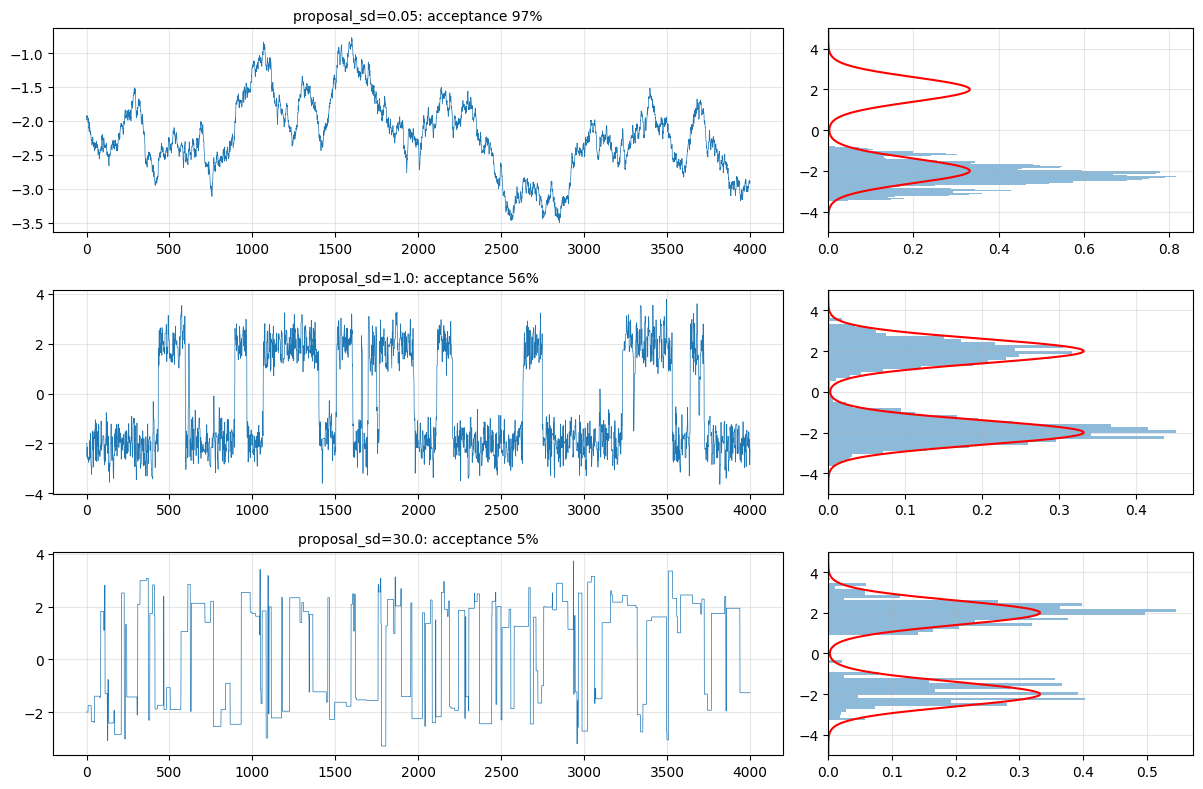

In [3]:
# Proposal width sweep on a bimodal target: trace + histogram for each width.
def log_bimodal(x):
    return np.logaddexp(stats.norm.logpdf(x, -2, 0.6), stats.norm.logpdf(x, 2, 0.6))


grid = np.linspace(-5, 5, 400)
target = np.exp([log_bimodal(g) for g in grid])
target /= np.trapezoid(target, grid)

fig, axes = plt.subplots(3, 2, figsize=(12, 8), width_ratios=[2, 1])
for row, sd in zip(axes, [0.05, 1.0, 30.0], strict=True):
    smp, rate = metropolis_hastings(log_bimodal, x0=-2.0, n_steps=4000,
                                    proposal_sd=sd, seed=1)
    row[0].plot(smp, lw=0.5)
    row[0].set_title(f"proposal_sd={sd}: acceptance {rate:.0%}", fontsize=10)
    row[0].grid(alpha=0.3)
    row[1].hist(smp[500:], bins=50, density=True, alpha=0.5, orientation="horizontal")
    row[1].plot(target, grid, "r", lw=1.5)
    row[1].set_ylim(-5, 5); row[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

- 歩幅 0.05: 受容率はほぼ 100% だが、4,000 歩かけても左の山から出られていない
- 歩幅 1.0: 両方の山を行き来し、ヒストグラムがターゲットに重なる
- 歩幅 30: ほぼ全部却下され、トレースが階段状(同じ値に何百歩も留まる)

### インタラクティブ(JupyterLab のみ)

In [4]:
# Interactive (JupyterLab only): slide the proposal width yourself.
from bayes_textbook.widgets import interactive_mcmc_sampler

interactive_mcmc_sampler()

interactive(children=(FloatLogSlider(value=1.0, description='proposal_sd', max=1.3, min=-1.5), Output()), _dom…

<function bayes_textbook.widgets.interactive_mcmc_sampler.<locals>.draw(proposal_sd)>

## 4. 診断 — burn-in・トレース・自己相関

MCMC のサンプルは独立ではありません。最低限見るべき 3 つ:

- **トレースプロット**: 「毛虫」のように見えれば良い。トレンドや張り付きは悪い兆候
- **burn-in**: 初期値の影響が残る序盤を捨てる
- **自己相関**: 何歩で「実質的に新しいサンプル」になるか(有効サンプルサイズの源)

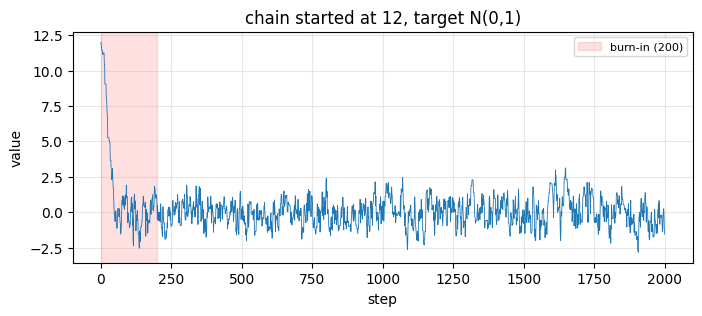

In [5]:
# Burn-in: start the chain far away and watch it find the target region.
smp_far, _ = metropolis_hastings(stats.norm.logpdf, x0=12.0, n_steps=2000,
                                 proposal_sd=0.8, seed=2)
viz.plot_trace(smp_far, burn_in=200, title="chain started at 12, target N(0,1)")
plt.show()

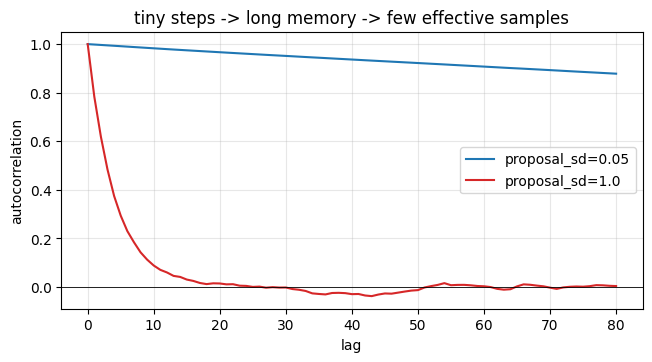

In [6]:
# Autocorrelation: small steps mix slowly, good steps decorrelate fast.
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for sd, color in [(0.05, "#1f77b4"), (1.0, "#d62728")]:
    smp, _ = metropolis_hastings(stats.norm.logpdf, x0=0.0, n_steps=8000,
                                 proposal_sd=sd, seed=3)
    acf = autocorrelation(smp[500:], max_lag=80)
    ax.plot(acf, color=color, label=f"proposal_sd={sd}")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("lag"); ax.set_ylabel("autocorrelation")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("tiny steps -> long memory -> few effective samples")
plt.show()

## 5. Gibbs サンプリング — 1 変数ずつ条件付きで引く

多次元で、**各変数の条件付き分布** $p(\theta_1 \mid \theta_2, x)$ が引けるなら、
変数を 1 つずつ交互にサンプリングできます(却下なし)。
相関の強い 2 変量正規では「階段状」に動くため、相関が強いほど遅くなります。

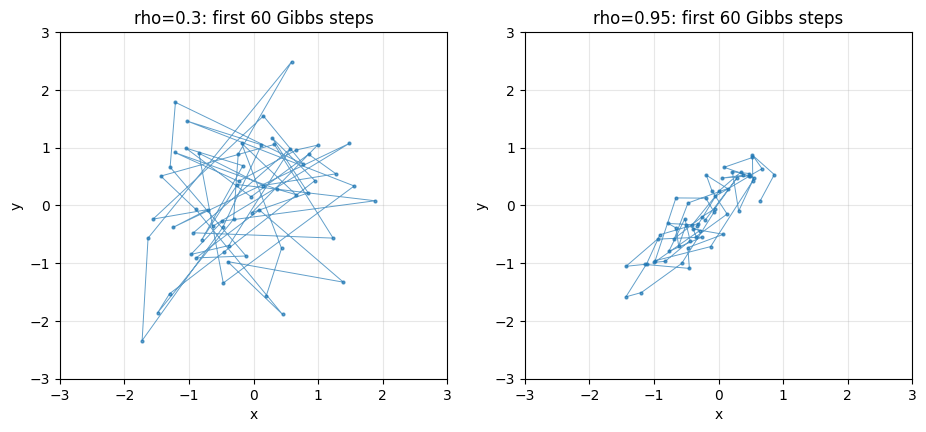

rho=0.95: empirical correlation of samples = 0.949


In [7]:
# Gibbs on a bivariate normal: staircase moves, slower when correlation is high.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, rho in zip(axes, [0.3, 0.95], strict=True):
    out = gibbs_bivariate_normal(rho, n_steps=300, seed=4)
    ax.plot(out[:60, 0], out[:60, 1], "-o", ms=2, lw=0.7, alpha=0.7)
    ax.set_title(f"rho={rho}: first 60 Gibbs steps")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.grid(alpha=0.3)
plt.show()
emp = np.corrcoef(gibbs_bivariate_normal(0.95, 20000, seed=5)[2000:].T)[0, 1]
print(f"rho=0.95: empirical correlation of samples = {emp:.3f}")

## 6. HMC — 物理で滑る

ランダムウォークの非効率(酔歩は $\sqrt{n}$ でしか進まない)を破るのが
**Hamiltonian Monte Carlo**。事後の対数密度を「地形」、サンプルを「ボール」と見て、

1. ランダムな運動量でボールを蹴る
2. ハミルトン力学(leapfrog 積分)で滑らせる
3. 着地点を MH 風の門番で受容

勾配を使って **遠くまで一気に、しかも高受容率で** 動けます。
ステップ数を自動調整するのが **NUTS**(No-U-Turn Sampler)で、PyMC の既定です(08 章)。

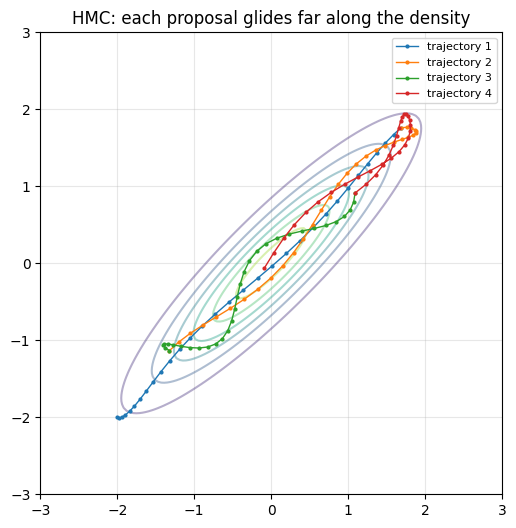

In [8]:
# Leapfrog trajectories on a 2-D Gaussian: long smooth sweeps, not a drunkard's walk.
cov = np.array([[1.0, 0.9], [0.9, 1.0]])
prec = np.linalg.inv(cov)


def grad_logp(q):
    return -prec @ q


fig, ax = plt.subplots(figsize=(6.5, 6))
g1, g2 = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
pts = np.stack([g1, g2], -1)
logp = -0.5 * np.einsum("...i,ij,...j->...", pts, prec, pts)
ax.contour(g1, g2, np.exp(logp), levels=8, alpha=0.4)
r = np.random.default_rng(0)
q = np.array([-2.0, -2.0])
for i in range(4):
    p = r.standard_normal(2)
    path = leapfrog(q, p, grad_logp, step_size=0.12, n_steps=30)
    ax.plot(path[:, 0], path[:, 1], "-o", ms=2, lw=1, label=f"trajectory {i + 1}")
    q = path[-1]
ax.set_title("HMC: each proposal glides far along the density")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.show()

## 7. なぜ MH で正しい分布が出るのか(詳細釣り合い)

MH の受容ルールは **詳細釣り合い条件** を満たすように作られています:

$$
\pi(\theta)\, T(\theta \to \theta') = \pi(\theta')\, T(\theta' \to \theta)
$$

「$\theta$ から $\theta'$ へ流れる確率質量」と逆方向の流れが釣り合う —
すると $\pi$(事後分布)はこの連鎖の **定常分布** になり、
十分歩けば滞在頻度が $\pi$ に収束します(エルゴード性)。
受容確率に **比** しか出てこないので、正規化定数 $p(x)$ が不要になるのでした。

## 8. まとめ

- MCMC は「事後の式」を諦めて「事後のサンプル」を取りに行く。比だけ使うので分母不要。
- **MH**: 提案 + 確率的な門番。歩幅は受容率 20〜50% を目安に調整。
- 診断の最低ライン: トレース・burn-in・自己相関。
- **Gibbs**: 条件付き分布が引けるなら却下なし。ただし強相関で遅い。
- **HMC/NUTS**: 勾配で滑って高次元でも効率的 — 現代の実務の既定(次章の PyMC へ)。

## 9. Exercises

1. §2 の MH で、`proposal_sd` を 0.01 にしたときの受容率と自己相関を確認せよ。
2. burn-in を捨てずに平均を取るとどれだけずれるか、§4 の遠い初期値の例で計算せよ。
3. ターゲットを $\mathrm{Gamma}(3, 1)$(非対称)にして MH でサンプリングし、
   理論平均 3 と比較せよ(負の提案は対数密度 $-\infty$ で自動的に却下される)。
4. Gibbs の例で `rho=0.99` のとき、自己相関が何ラグまで残るか調べよ。
5. (発展)leapfrog の `step_size` を大きくしすぎると軌道が発散する
   (エネルギー保存が壊れる)ことを確認せよ。NUTS がステップ調整を自動化する動機である。